# MFIS $_{t-1} + DMO \rightarrow$ MFIS $_t$

In [ ]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.core.data_transforms import Transform
from src.train import LSTMRegressionXV

import torch

In [28]:
K_FOLDS = 5
N_VISITS = 4

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [30]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam

config = ModelConfig(
    name="lstm_regression",
    model_type="LSTM",
    input_size=169,
    hidden_size=128,
    num_layers=1,
    output_size=1,
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
)

config.notes = "None"

In [31]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
]

In [32]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
    #static_features=static_features
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [33]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [34]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [35]:
# remove missing labels
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [36]:
dmo_labels.shape

torch.Size([428, 4, 1])

In [37]:
# Min max normalise all fatigue values
physical_subset_max = 36
dmo_labels = dmo_labels / physical_subset_max

In [38]:
dmo_data = dmo_data.flatten(start_dim=2, end_dim=3)
dmo_data.shape

torch.Size([428, 4, 168])

In [39]:
fatigue_to_concat = torch.zeros(dmo_labels.shape)
fatigue_to_concat[:, 1:, :] = dmo_labels[:, :-1, :]
fatigue_to_concat.shape

torch.Size([428, 4, 1])

In [40]:
fatigue_to_concat[0]

tensor([[0.0000],
        [0.1944],
        [0.4167],
        [0.6389]])

In [41]:
dmo_labels[0]

tensor([[0.1944],
        [0.4167],
        [0.6389],
        [0.3611]])

In [26]:
dmo_data.shape

torch.Size([428, 4, 168])

In [16]:
dmo_input = torch.cat((dmo_data, fatigue_to_concat), dim=2)

In [17]:
dmo_input.shape

torch.Size([428, 4, 169])

In [18]:
dmo_labels.shape

torch.Size([428, 4, 1])

In [21]:
xv_trainer = LSTMRegressionXV(dmo_input, dmo_labels, config, device, k=K_FOLDS)
prediction, actual = xv_trainer.train_cross_validation()

Testing loss: 0.049537781005104385
Testing loss: 0.059013242522875466
Testing loss: 0.04789888300001621
Testing loss: 0.05549387137095133
Testing loss: 0.0877538373072942


In [22]:
prediction = torch.concatenate(prediction).flatten().reshape(dmo_labels.shape)
prediction = (prediction * physical_subset_max).flatten()
prediction.shape

torch.Size([1712])

In [23]:
actual = torch.concatenate(actual).flatten().reshape(dmo_labels.shape)
actual = (actual * physical_subset_max).flatten()
actual.shape

torch.Size([1712])

In [24]:
print(xv_trainer.R2_values)

[0.08260810375213623, -0.06482911109924316, 0.045324087142944336, -0.12992942333221436, -0.518856406211853]


All metrics: {'accuracy': 0.014602803738317757, 'Mean Squared Error': 77.86212921142578, 'Mean Absolute Error': 6.920948505401611, 'R^2': -0.11787569522857666}


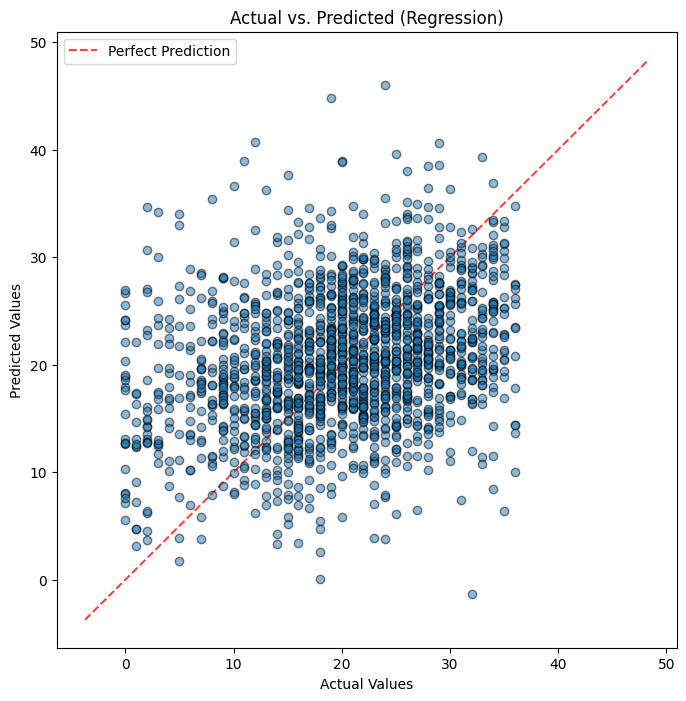

In [25]:
from src.evaluation import Evaluation

evaluation = Evaluation(prediction, actual)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
